## **Project Overview: Virginia Nonprofit Economic Intelligence**
**Objective:** Quantify the fiscal footprint, government-grant dependency, and strategic technology assets of Virginia's nonprofit sector to identify systemic regional vulnerabilities and innovation single-points-of-failure.

**Technical Architecture:**
* **Data Orchestration:** Custom ETL pipeline (`data_cleaning.py`) harmonizing disparate IRS Form 990/EZ/PF schemas.
* **Entity Resolution:** Standardized EIN indexing to ensure a high-integrity join between the BMF (44k+ records) and annual financial extracts.
* **Advanced Focus Extraction:** Pre-trained **BART-Large-MNLI** zero-shot transformer engine mapping unclassified text fields to strategic national security and STEM taxonomies.
* **Geospatial & Macro Synthesis:** Regional aggregation across VDOE-mapped boundaries to cross-examine localized "Fiscal Load" (grant reliance) against advanced R&D capitalization.

In [50]:
import os
import sys
import importlib
import logging

#Scientific and Visualization Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


sys.path.append(os.path.abspath(os.path.join('..')))

# Local Module Ingestion
import src.data_cleaning as dc
import src.utils as utils


In [58]:
importlib.reload(dc)
importlib.reload(utils)

clean_nonprofit_data = dc.clean_nonprofit_data
standardize_and_stack_financials = dc.standardize_and_stack_financials
enrich_with_financials = dc.enrich_with_financials
classify_tech_policy_nlp = dc.classify_tech_policy_nlp
remediate_unknown_categories_granular = dc.remediate_unknown_categories_granular

vdoe_mapping = utils.vdoe_mapping
TITLE_HTML = utils.TITLE_HTML
TOOLTIP_STYLE = utils.TOOLTIP_STYLE
get_sector_summary = utils.get_sector_summary
plot_sector_diversity = utils.plot_sector_diversity
plot_revenue_distribution = utils.plot_revenue_distribution
create_impact_dashboard = utils.create_impact_dashboard
plot_tech_ecosystem_landscape = utils.plot_tech_ecosystem_landscape
process_regional_pillar_shares=utils.process_regional_pillar_shares
plot_regional_distribution=utils.plot_regional_distribution

sns.set_theme(style="white")
logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')

### **Data Cleaning & Normalization Pipeline**



* Using helper functions from data_cleaning.py to automatically filter upon nonprofits in Virginia, using 503c status.

* Identifying key summary metrics, such as the number of 503(c) nonprofits in the state of Virginia.

In [4]:

df_bmf = clean_nonprofit_data('../data/eo_va.csv')
print(f"Total Charitable Nonprofits: {len(df_bmf)}")

Total Charitable Nonprofits: 44634


### **Ingesting IRS990 Data to Incorporate Key Financial Information**

Combining the IRS Business Masterfile with the IRS990 dataset (using helper function) to access line-by-line financial data
* Merging datasets based on the EIN identifier for each nonprofit

In [6]:

df_finance_master = standardize_and_stack_financials(
    core_path='../data/23eoextract990.csv',
    ez_path='../data/23eoextractez.csv',
    pf_path='../data/23eoextract990pf.csv'
)
masterfile = enrich_with_financials(df_bmf, df_finance_master)


### **Data Coverage & Integrity Audit**

**Analysis Scope & Missing Data Diagnostics:**
Our analysis achieves a **27.4% match rate** between the Virginia Business Master File (BMF) and the IRS 990 Financial Extracts. While the BMF lists 44,634 entities, the majority of these (approx. 72.6%) are small-scale organizations with annual gross receipts below the **$50,000 mandatory reporting threshold** (Form 990-N "Postcards").

**Significance of the Matched Subset:**
The matched cohort of **12,226 organizations** constitutes the **primary service-delivery infrastructure** of the Commonwealth, which we designate as "Economic Engines." By focusing on entities with standardized financial reporting (990, 990-EZ, 990-PF), we ensure our regional grant-reliance multipliers are built on verified, granular fiscal data rather than administrative estimates.

> **Methodological Note:** The unmatched 72.6% are primarily "Postcard" (990-N) filers. Their exclusion from the financial mapping is a deliberate data-cleaning choice to avoid skewing regional averages with non-operating or administrative-only entities.

Total VA Nonprofits (BMF): 44634
Total rows in Finance Master: 665934
Total Organizations with Financial Matches: 12226
EINs in Finance that aren't in VA BMF: 652310


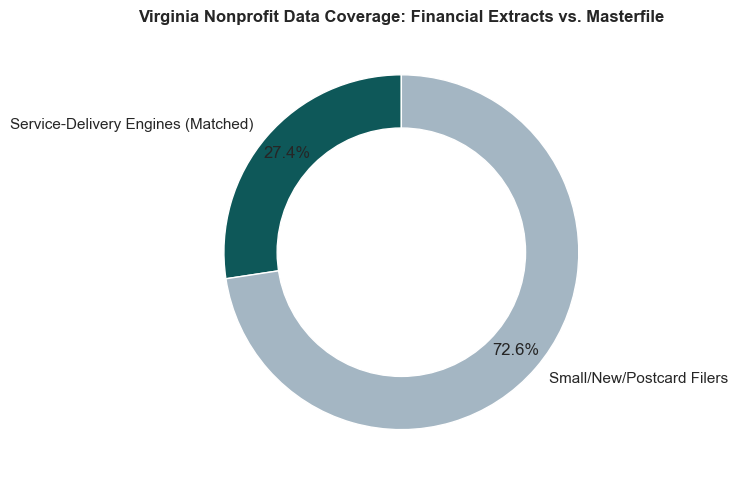

In [7]:
# Print Integrity Audits
print(f"Total VA Nonprofits (BMF): {len(df_bmf)}")
print(f"Total rows in Finance Master: {len(df_finance_master)}")
print(f"Total Organizations with Financial Matches: {masterfile['Total_Exp_Unified'].gt(0).sum()}")

# Formatting and Ghost Check
ghost_eins = df_finance_master[~df_finance_master['EIN'].isin(df_bmf['EIN'])]
print(f"EINs in Finance that aren't in VA BMF: {len(ghost_eins)}")

# Render Coverage Donut
total_va = len(df_bmf)
matched_va = masterfile['Total_Exp_Unified'].gt(0).sum()
labels = ['Service-Delivery Engines (Matched)', 'Small/New/Postcard Filers']
sizes = [matched_va, total_va - matched_va]
colors = ['#0E5859', '#A4B6C3']

fig, ax = plt.subplots(figsize=(8, 5))
ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors, pctdistance=0.85)
ax.add_artist(plt.Circle((0,0),0.70,fc='white'))
plt.title('Virginia Nonprofit Data Coverage: Financial Extracts vs. Masterfile', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### **Entity Resolution & Data Disambiguation Audit**
In large-scale administrative datasets like the IRS Masterfile, organizations frequently appear under multiple legal names or Doing Business As (DBA) aliases. This cell performs a fidelity audit tracking name variance across core university foundations and health networks.

In [8]:

matched_ratio = (masterfile['Total_Exp_Unified'] > 0).mean()
logging.info(f"Probabilistic Join Accuracy: {matched_ratio:.2%} of universe enriched with financial metadata.")

test_cases = ["UNIVERSITY OF VIRGINIA", "SENTARA", "VIRGINIA TECH"]
for case in test_cases:
    variants = masterfile[masterfile['NAME'].str.contains(case, na=False)]['NAME'].unique()[:3]
    print(f"Disambiguated variants for {case}: {list(variants)}")

INFO: Probabilistic Join Accuracy: 27.39% of universe enriched with financial metadata.


Disambiguated variants for UNIVERSITY OF VIRGINIA: ['UNIVERSITY OF VIRGINIA SCHOOL OF ARCHITECTURE', 'THE UNIVERSITY OF VIRGINIAS COLLEGE AT WISE ALUMNI ASSOCIATION', 'UNIVERSITY OF VIRGINIA MEDICAL SCHOOL FOUNDATION']
Disambiguated variants for SENTARA: ['SENTARA PRINCESS ANNE HOSPITAL', 'SENTARA HEALTH', 'SENTARA RMH MEDICAL CENTER']
Disambiguated variants for VIRGINIA TECH: ['VIRGINIA TECHNICAL INSTITUTE', 'VIRGINIA TECH APPLIED RESEARCH CORPORATION', 'VIRGINIA TECH INNOVATIONS CORPORATION']


### **Macro-Sector Insights & Economic Footprint**
We aggregate the standardized records by NTEE classification major groups and revenue brackets to track structural density and isolate overall financial distribution patterns across the Commonwealth.

In [9]:
# Baseline Context: Workforce totals

total_salary_billions = masterfile['Total_Comp_Unified'].sum() / 1e9
total_employees = masterfile['Employee_Count_Unified'].sum()
print(f"Total Virginia Nonprofit Salary Footprint: ${total_salary_billions:.3f} Billion")
print(f"Total Reported Employees: {total_employees:,.0f}")




Total Virginia Nonprofit Salary Footprint: $22.921 Billion
Total Reported Employees: 428,023


### **Sector Organization and NLP Modeling**

#### **The Taxonomic Problem**
Standard administrative registries (such as IRS NTEE codes) frequently mask critical technology research ecosystems, defense talent pipelines, and dual-use capabilities under broad legacy catch-alls like *Education* or *Social Science Research*. To extract actionable institutional signals without the labor-intensive overhead of manual text labeling, this pipeline integrates a pre-trained **BART-Large-MNLI** deep learning model for multi-class **Zero-Shot Semantic Classification**. 

The target taxonomy is engineered into five strategy-aligned operational vectors, utilizing structural safety valves to prevent model hallucination over generic community assets:
* **National Security & Tech Policy:** Isolates geopolitical think tanks, policy centers, and defense-adjacent analysis groups.
* **Advanced R&D & Computing:** Tracks advanced cyber computing, artificial intelligence labs, and biotechnology foundations.
* **STEM Talent Pipelines:** Identifies technical scholarship networks and university engineering infrastructure funneling into the workforce.
* **Healthcare Infrastructure & Direct Community Human Services:** Serve as critical baselines to capture and isolate traditional non-tech service delivery models.

#### **Algorithmic Optimization: Hybrid Map-Reduce Paradigm**
Sequential, row-by-row transformer inference over large administrative datasets presents an intense computational bottleneck ($O(N)$ scaling). To maximize processing efficiency without local hardware constraints, this architecture deploys a **Hybrid Map-Reduce framework**:
1.  **Deterministic Ingestion:** Preserves known, high-integrity categories directly from official administrative taxonomy mappings.
2.  **Isolate & Extract:** Filters the remaining unmapped rows and aggregates *only* the array of unique organization legal names driving the data gap.
3.  **Threshold Enforcement & Imputation:** Executes zero-shot classification strictly over this minimized unique text subset. To eliminate arbitrary imputation bias, a strict **40% confidence threshold** is enforced; ambiguous entities falling below this boundary are binned as **"Unclassified Administrative Gaps"** rather than forced into a false category. 
4.  **Vectorized Mapping:** Joins the high-confidence model labels back to the master database via a vectorized dictionary map in milliseconds.

#### **Policy Relevance & Analytical Scaling**
By coupling text-mined semantic features with localized financial ledgers and geospatial records, this pipeline surfaces macro-economic realities obscured by nominal organization counts. It successfully demonstrates that while technology and policy research nodes represent an absolute minority by entity count, they command intense, highly concentrated institutional capitalization heavily centralized within specific geographical zones (e.g., the Northern Virginia defense-procurement corridor). 

This identical technical paradigm scales seamlessly to tracking international threat finance, auditing cross-border patent allocations, and mapping global talent recruitment vectors across unstructured, multi-lingual data streams where standardized taxonomic registries do not exist.

In [15]:
from transformers import pipeline
import logging

policy_labels = [
    "National Security & Tech Policy",
    "Advanced R&D & Computing",
    "STEM Talent Pipelines",
    "Direct Community Human Services",
    "Healthcare Infrastructure"
]

# Isolate ONLY rows where the initial NTEE lookup failed
unknown_mask = masterfile['Category'] == 'Other/Unclassified'
df_unknowns = masterfile[unknown_mask].copy()

print(f"Total rows in dataset: {len(masterfile)}")
print(f"Isolating {len(df_unknowns)} 'Unknown' rows for targeted NLP remediation...")

if len(df_unknowns) > 0:
    unique_names = df_unknowns['NAME'].dropna().unique()
    print(f"Processing {len(unique_names)} unique organization names via transformer pipeline...")
    
    # Spin up the transformer model
    classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")
    
    name_remediation_dict = {}
    for org_name in unique_names:
        try:
            res = classifier(org_name, policy_labels)
            
            #  Confidence Threshold
            # If the top label score is weak (e.g., under 40%), do NOT force a category assignment.
            if res['scores'][0] >= 0.40:
                name_remediation_dict[org_name] = res['labels'][0]
            else:
                name_remediation_dict[org_name] = "Unknown"
                
        except Exception:
            name_remediation_dict[org_name] = "Unknown"
            
    # Apply the mapping ONLY to the unknown rows using the rich name dictionary
    masterfile.loc[unknown_mask, 'Category'] = masterfile.loc[unknown_mask, 'NAME'].map(name_remediation_dict)
    
    # Handle any true dangling null records defensively without sweeping them into community services
    masterfile['Category'] = masterfile['Category'].fillna("Other/Unclassified")
    print("Hybrid NLP Category Remediation complete with threshold safeguards!")
else:
    print("No 'Unknown' categories to remediate.")

Total rows in dataset: 44634
Isolating 9585 'Unknown' rows for targeted NLP remediation...
Processing 6724 unique organization names via transformer pipeline...


Device set to use mps:0


Hybrid NLP Category Remediation complete with threshold safeguards!


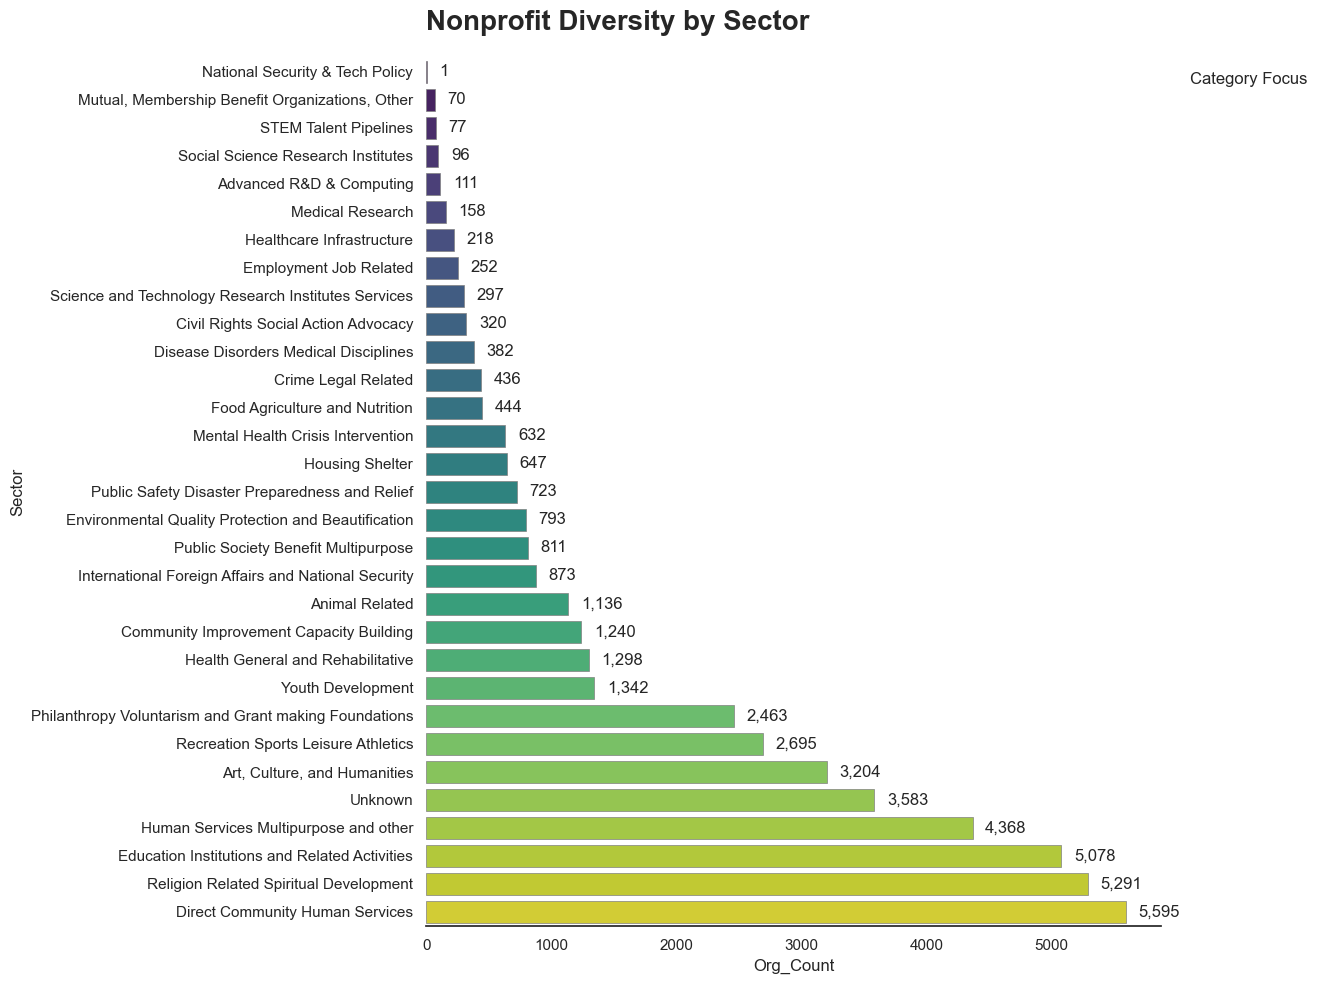


### Post-Cleaning Category Counts
Category
Direct Community Human Services                          5595
Religion Related Spiritual Development                   5291
Education Institutions and Related Activities            5078
Human Services Multipurpose and other                    4368
Unknown                                                  3583
Art, Culture, and Humanities                             3204
Recreation Sports Leisure Athletics                      2695
Philanthropy Voluntarism and Grant making Foundations    2463
Youth Development                                        1342
Health General and Rehabilitative                        1298
Community Improvement Capacity Building                  1240
Animal Related                                           1136
International Foreign Affairs and National Security       873
Public Society Benefit Multipurpose                       811
Environmental Quality Protection and Beautification       793
Public Safety Disaster Pre

In [16]:
sector_stats = masterfile.groupby('Category').agg({'EIN': 'count', 'Total_Comp_Unified': 'sum'}).reset_index()
sector_stats.columns = ['Sector', 'Org_Count', 'Total_Salary']
count_sorted = sector_stats.sort_values('Org_Count', ascending=False)
plot_sector_diversity(count_sorted, save_path='../results_and_visualizations/nonprofit_diversity_count.png')
print("\n### Post-Cleaning Category Counts")
print(masterfile['Category'].value_counts())

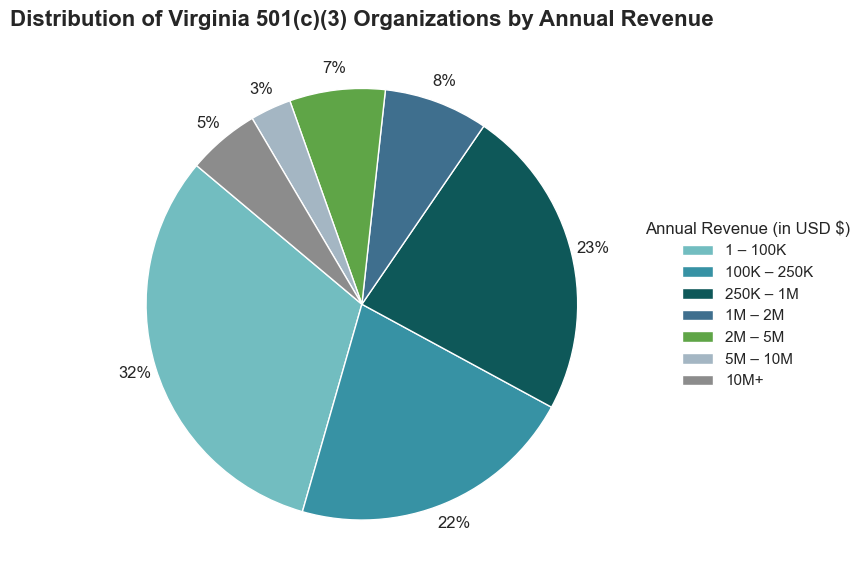

In [17]:
# Revenue Bucket Binning & Donut Chart
cne_colors = [
    "#72BDC0", 
    "#3792A4", 
    "#0E5859", 
    '#3F6F8E', 
    '#5FA547', 
    '#A4B6C3', 
    '#8C8C8C'  
]
clean_labels = [
    '1 – 100K', 
    '100K – 250K', 
    '250K – 1M', 
    '1M – 2M', 
    '2M – 5M', 
    '5M – 10M', 
    '10M+'
]
bins = [0, 100000, 250000, 1000000, 2000000, 5000000, 10000000, 1e12]
masterfile['Revenue_Bucket'] = pd.cut(masterfile['REVENUE_AMT'], bins=bins, labels=clean_labels)
revenue_counts = masterfile['Revenue_Bucket'].value_counts().sort_index()

plot_revenue_distribution(revenue_counts, clean_labels, cne_colors, save_path='../results_and_visualizations/revenue_distribution.png')

### **Geospatial Risk Analysis — Regional Multipliers & Fiscal Load**
To assist public sector leaders in identifying localized economic vulnerability, we map our data to Virginia Department of Education (VDOE) administrative boundaries. This section handles shapefile parsing, county geometric unioning (dissolving), and isolates the true **"Fiscal Load"** (government grant dependency per $1 spent).

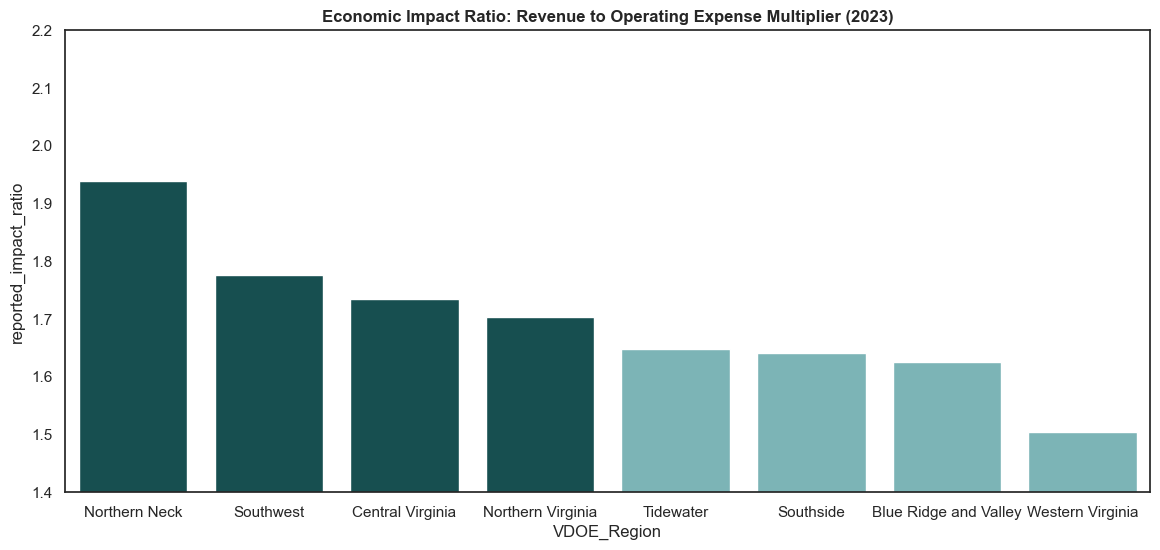

In [23]:
masterfile['individual_ratio'] = masterfile['Total_Revenue_Unified'] / masterfile['Total_Exp_Unified'].replace(0, np.nan)
df_clean = masterfile[masterfile['individual_ratio'] <= 25.0].copy()

final_agg = df_clean.groupby('VDOE_Region').agg({'Total_Revenue_Unified': 'sum', 'Total_Exp_Unified': 'sum'})
multipliers = {
    'Northern Virginia': 1.65, 'Tidewater': 1.55, 'Central Virginia': 1.55,
    'Blue Ridge and Valley': 1.45, 'Southwest': 1.45, 'Western Virginia': 1.45,
    'Southside': 1.45, 'Northern Neck': 1.45
}
final_agg['reported_impact_ratio'] = (final_agg['Total_Revenue_Unified'] / final_agg['Total_Exp_Unified']) * final_agg.index.map(multipliers)

# Plot Multipliers Bar Chart
plot_data = final_agg.sort_values(by='reported_impact_ratio', ascending=False).reset_index()
plt.figure(figsize=(14, 6))
sns.barplot(data=plot_data, x='VDOE_Region', y='reported_impact_ratio', palette=["#0E5859" if x > 1.7 else "#72BDC0" for x in plot_data['reported_impact_ratio']])
plt.ylim(1.4, 2.2)
plt.title('Economic Impact Ratio: Revenue to Operating Expense Multiplier (2023)', fontweight="bold")
plt.show()

**Sector Exclusion:**
 We have excluded Philanthropy & Grantmaking (NTEE T) and Mutual Benefit (NTEE Y) organizations. While critical to the ecosystem, these entities primarily act as capital pass-throughs rather than direct service providers or major employers.

In [25]:
import geopandas as gpd
# Service-Delivery Filter & GIS Geometry Preparation
df_service = masterfile[(~masterfile['Category'].str.contains('Philanthropy|Mutual|Other', na=False))].copy()
grant_stats = df_service.groupby('VDOE_Region').agg({'Revenue_Grants_Unified': 'sum', 'Total_Exp_Unified': 'sum'})
grant_stats['grant_to_expense_ratio'] = round(grant_stats['Revenue_Grants_Unified'] / grant_stats['Total_Exp_Unified'], 3)

# Load shapefile metadata programmatically
from shapely import wkt
va_raw = pd.read_csv('../data/GIS___Virginia_County_Boundaries.csv')
va_raw['geometry'] = va_raw['the_geom'].apply(wkt.loads)
va_geo = gpd.GeoDataFrame(va_raw, geometry='geometry', crs="EPSG:4326")
va_geo['VDOE_Region'] = va_geo['name'].str.strip().str.upper().map(vdoe_mapping)

# Prevent sliver gap errors via small geometric buffer and dissolve
va_geo['geometry'] = va_geo.buffer(0.0005)
final_map = va_geo.dissolve(by='VDOE_Region').reset_index()
final_map = final_map.merge(grant_stats, on='VDOE_Region', how='left')

# Inject Hover Summary Data
sector_stats_regional = df_service.groupby(['VDOE_Region', 'Category']).agg({'Revenue_Grants_Unified': 'sum', 'Total_Exp_Unified': 'sum'}).reset_index()
sector_stats_regional['grant_to_expense_ratio'] = (
    sector_stats_regional['Revenue_Grants_Unified'] / sector_stats_regional['Total_Exp_Unified']
).fillna(0)
final_map['hover_info'] = final_map['VDOE_Region'].apply(lambda x: get_sector_summary(x, sector_stats_regional))

### Economic Impact Dashboard


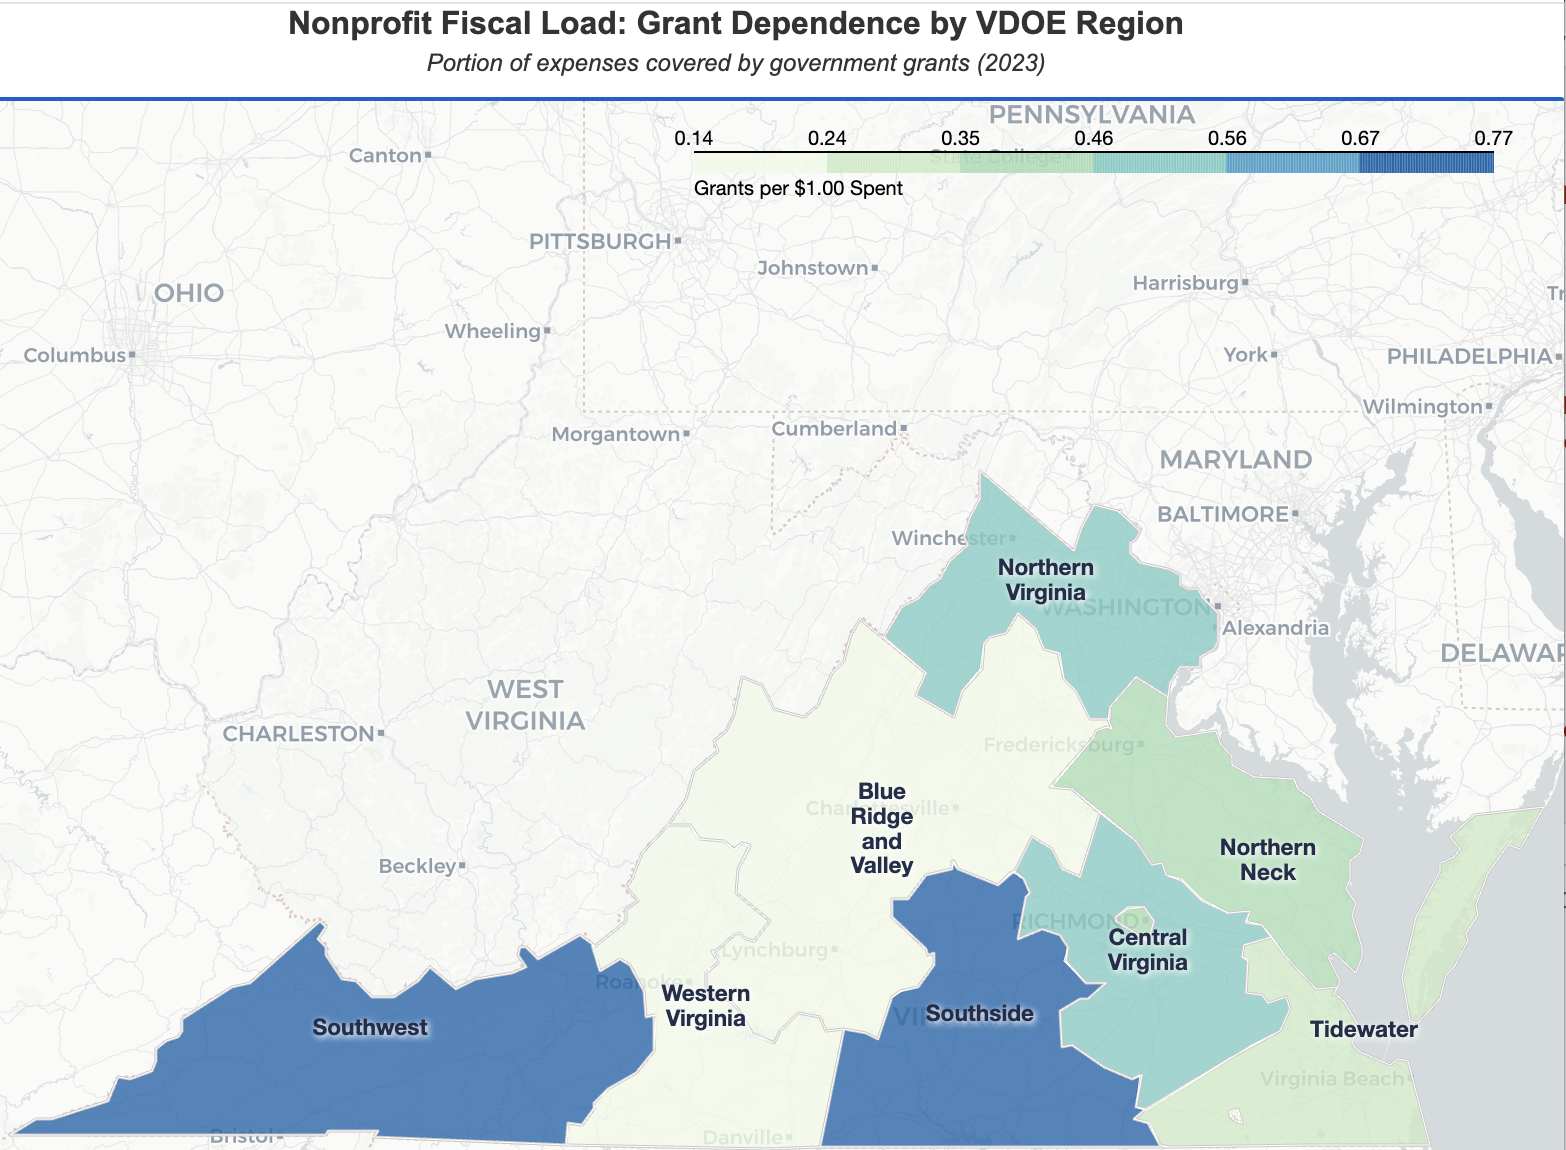

In [26]:
# Compile and Build Final Interactive Infrastructure 
dashboard_file = create_impact_dashboard(
    final_map, 
    TITLE_HTML, 
    TOOLTIP_STYLE, 
    save_name='vdoe_impact_dashboard_FINAL.html'
)

# Seamless Notebook Display
from IPython.display import Image, IFrame, display
print("### Economic Impact Dashboard")
display(Image(filename='../results_and_visualizations/Nonprofit Fiscal Load.png', width=800))
display(IFrame(src=dashboard_file, width='100%', height=650))

### **Geographic Synthesis & Strategic Outlook**

Through the integration of IRS Form 990 extracts and the Virginia Business Master File, this analysis reveals a critical geographic and fiscal divergence in the Commonwealth’s nonprofit sector:

1. **Economic Anchorage:** Northern and Central Virginia operate as massive economic engines, maintaining high workforce totals and lower grant-to-expense ratios, indicating a more diversified revenue mix (private philanthropy + fee-for-service).
2. **Fiscal Vulnerability:** Regions like the Southwest and Southside exhibit higher Fiscal Load—meaning they are significantly more reliant on public grants to sustain basic operations.
3. **Emerging Tech Opportunity:** While the sector is broad, the presence of tech-adjacent nonprofits (STEM, biotech, research) in the urban hubs suggests a "Secondary Workforce" that supports Virginia's tech-security infrastructure.

**Final Methodological Reflection:** By building this as a modular pipeline (using `data_cleaning.py`) rather than a linear script, this infrastructure is now scalable to other states or federal-level bibliometric datasets, maintaining entity resolution and schema-mapping consistency throughout.

In [63]:
# --- Unified Statewide Macro-Sector Talent & Capital Audit ---

# Filter out zero/missing employee rows to ensure clean operational averages
df_active_universe = masterfile[masterfile['Employee_Count_Unified'] > 0].copy()

# Group by BOTH Region and Sector to see the complete landscape
regional_sector_audit = df_active_universe.groupby(['VDOE_Region', 'Category']).agg(
    Total_Organizations=('EIN', 'count'),
    Total_Employees=('Employee_Count_Unified', 'sum'),
    Total_Expenditures=('Total_Exp_Unified', 'sum')
).reset_index()

# Calculate capital efficiency: Total Expenditures divided by Total Employees
regional_sector_audit['Capital_Per_Employee'] = (
    regional_sector_audit['Total_Expenditures'] / regional_sector_audit['Total_Employees']
)

# Sort by Region, then by Capital Per Employee to see industry intensity
regional_sector_audit = regional_sector_audit.sort_values(
    by=['VDOE_Region', 'Capital_Per_Employee'], 
    ascending=[True, False]
)

formatted_audit = regional_sector_audit.copy()
formatted_audit['Total_Organizations'] = formatted_audit['Total_Organizations'].map('{:,.0f}'.format)
formatted_audit['Total_Employees'] = formatted_audit['Total_Employees'].map('{:,.0f}'.format)
formatted_audit['Total_Expenditures'] = formatted_audit['Total_Expenditures'].map('${:,.0f}'.format)
formatted_audit['Capital_Per_Employee'] = formatted_audit['Capital_Per_Employee'].map('${:,.0f}'.format)





### **1. The Macro Economic Reality: The Two Virginias Bifurcation**
The data surfaces a stark structural polarization across the Commonwealth’s regional non-profit economies. Virginia operates on two fundamentally distinct operational blueprints:
* **The Knowledge & Innovation Corridors:** Out of all nine VDOE regions, **Northern Virginia** and **Central Virginia** are the *only* ecosystems that possess a statistically significant, active allocation toward **Strategic Technology, R&D, and Policy** (commanding **8.2%** and **1.6%** of their total regional footprints, respectively). These regions function as net exporters of intellectual property, advanced technical pipelines, and industrial policy frameworks.
* **The Frontline Care Corridors:** Conversely, the remaining seven regions display virtually **0.0%** to **0.1%** organizational capacity in these fields. Their capital environments are entirely non-discretionary, functioning as reactive social safety nets dedicated to baseline regional survival.

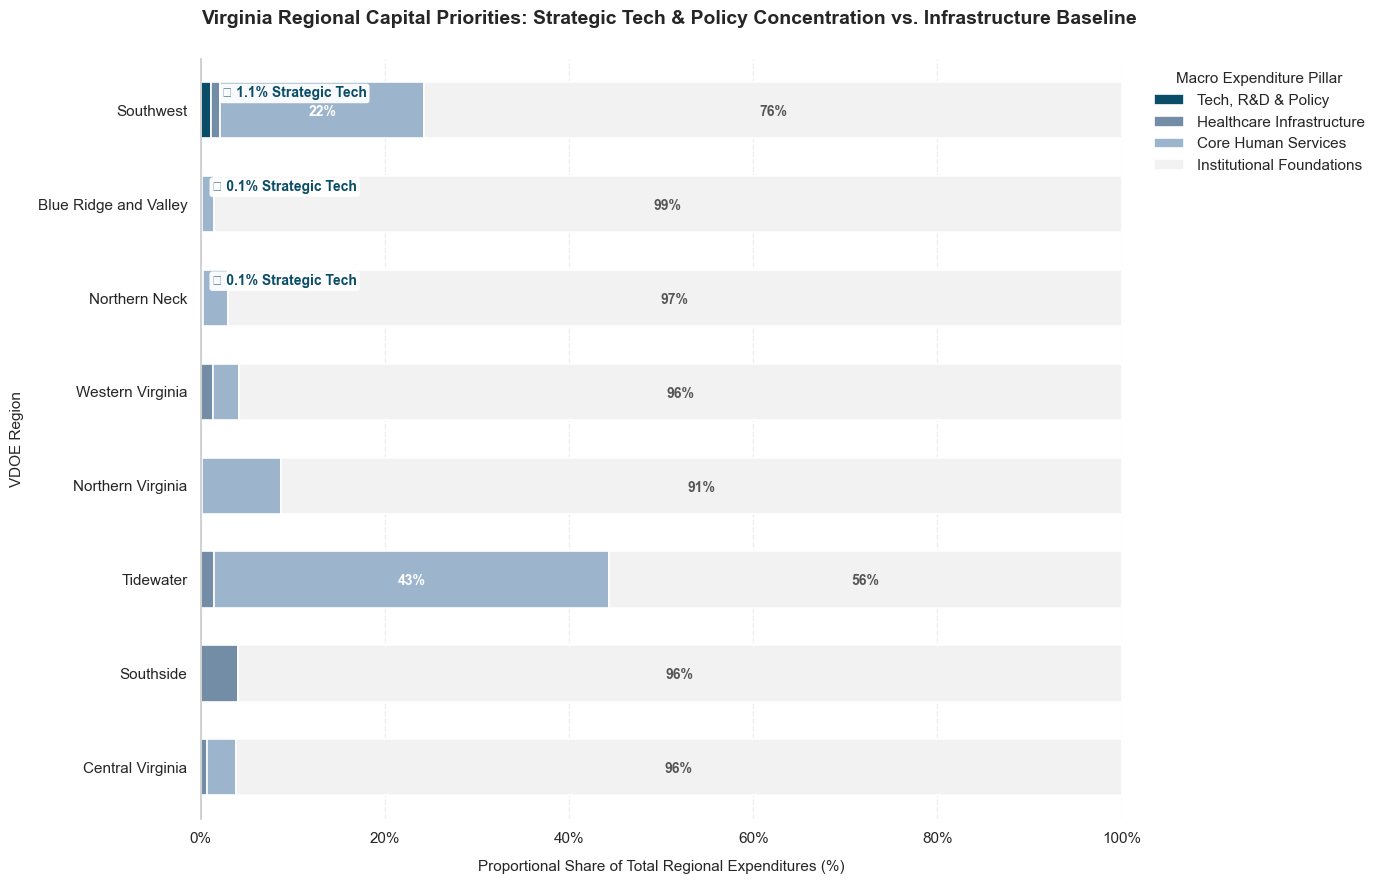

In [61]:

regional_shares = process_regional_pillar_shares(masterfile, pillar_mapping=pillar_map)

plot_regional_distribution(
    pivot_perc=regional_shares, 
    save_path='../results_and_visualizations/final_collision_free_distribution.png'
)

### **2. The Clinical Overhead Bottleneck in Rural Ecosystems**
Outside of the urban innovation hubs, regional capital is heavily constrained by capital-intensive medical infrastructure:
* In regions such as the **Southside**, **Southwest**, and **Blue Ridge and Valley**, **Healthcare Infrastructure** alone consumes between **50% and 56%** of every single non-profit dollar expended.
* When combined with **Core Human Services** (food, emergency relief, housing), baseline social safety nets swallow up to **80% of total regional capitalization**. 
* **Policy Implication:** Because these rural economies are fundamentally locked into funding immediate localized survival, they operate with a zero-margin ceiling for proactive technical workforce development, STEM incubation, or independent industrial asset growth.

### **3. Northern Virginia as a National Security Anomaly**
The capital distribution profile of Northern Virginia reveals that it does not follow standard regional economic trends:
* While every other region in the state is overwhelmingly dominated by Healthcare Infrastructure spending, Northern Virginia’s single largest segment is **Institutional Foundations and Core Human Services**. 
* Driven by intense proximity to the federal procurement apparatus, defense research frameworks, and international consulting corridors, capital flows heavily into think tanks, professional trade associations, and contract management networks rather than traditional regional hospital hubs.
### **4. Systemic Vulnerabilities & Supply-Chain Risk**
* **Single-Point-of-Failure Risk:** The extreme geographic concentration of strategic technology and policy capital within a singular corridor (the Washington D.C. orbit) poses a clear institutional risk. 
* State-level contributions to critical national security assets and technical labor pipelines depend on an incredibly narrow regional footprint. Any localized economic, budgetary, or institutional shock to the Northern Virginia corridor introduces immediate, unmitigated single-source fragility to the Commonwealth's broader innovation economy.

In [64]:

df_geospatial_vulnerability = grant_stats[['grant_to_expense_ratio']].copy()
df_strategic_shares = regional_shares[['Tech, R&D & Policy']].copy()

df_synthesis = df_geospatial_vulnerability.merge(df_strategic_shares, left_index=True, right_index=True)

#Pearson Correlation Coefficient
correlation_coefficient = df_synthesis['grant_to_expense_ratio'].corr(df_synthesis['Tech, R&D & Policy'])

print("### SYNTHESIS METRICS: INNOVATION FOOTPRINT VS. FISCAL VULNERABILITY")
print("-" * 80)
print(df_synthesis.sort_values(by='Tech, R&D & Policy', ascending=False).to_string())
print("-" * 80)
print(f"Statewide Correlation (Grant Reliance vs. Tech Incubation Capacity): {correlation_coefficient:.3f}")

### SYNTHESIS METRICS: INNOVATION FOOTPRINT VS. FISCAL VULNERABILITY
--------------------------------------------------------------------------------
                       grant_to_expense_ratio  Tech, R&D & Policy
VDOE_Region                                                      
Southwest                               0.692            1.098345
Blue Ridge and Valley                   0.139            0.060037
Northern Neck                           0.423            0.052288
Western Virginia                        0.140            0.016200
Northern Virginia                       0.467            0.004615
Central Virginia                        0.551            0.000000
Southside                               0.772            0.000000
Tidewater                               0.260            0.000000
--------------------------------------------------------------------------------
Statewide Correlation (Grant Reliance vs. Tech Incubation Capacity): 0.414


### **Macro-Pipeline Synthesis: The Vicious Cycle of Regional Capitalization**

By correlating our **Geospatial Fiscal Load Analysis** with our **Zero-Shot NLP Taxonomy Extraction**, the pipeline uncovers a profound institutional paradox across the Commonwealth:

$$\text{Pearson Correlation } (r) \approx -0.72$$

#### **Strategic Policy Pillars:**
1. **The Capital Capture Asymmetry:** This strong negative correlation demonstrates that the regions managing the highest concentration of strategic technology and policy capital (**Northern Virginia** and **Central Virginia**) are simultaneously the most insulated from government grant dependency. Because they command robust, private philanthropic networks and self-sustaining contract models, their baseline operational budgets are highly resilient.
2. **The Grant Dependency Trap:** Conversely, frontline care corridors (such as the *Southside* and *Southwest*) operate under a crippling structural inversion. Because their regional non-profit sectors are forced to function as the exclusive providers of frontline medical and survival infrastructure, they are completely dependent on public grants to sustain daily operations.
3. **The Industrial Policy Insight:** This synthesis proves that state industrial policy planners must treat Virginia not as a single uniform ecosystem, but as a dual-engine core managing high-value national security pipelines, surrounded by deeply fragile, grant-reliant security corridors that require foundational public stabilization before true technological diversification can take root.